## Step 1: Import Data & Data Prepocessing


In [ ]:
# ============================================================
#  Bangkok PM2.5 Predictor — Multiple Linear Regression
#  CS462 Data Analytics and Mining
#  ใช้ pm10, o3, no2, so2, co → ทำนาย pm25
# ============================================================

# ── STEP 1: ติดตั้ง / Import ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_regression, SelectKBest

In [ ]:
# ── STEP 2: โหลดข้อมูล & จัดการชื่อคอลัมน์ ──────────────────
import io
from google.colab import files

# 1. อัปโหลดไฟล์ (ถ้ายังไม่ได้อัปโหลด)
uploaded = files.upload()

# 2. อ่านไฟล์ CSV จากที่อัปโหลดมาล่าสุด
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# 🛠 แก้ Error: ลบช่องว่างที่อาจติดมากับชื่อคอลัมน์ (เช่น ' pm25' -> 'pm25')
df.columns = df.columns.str.strip()

# 3. จัดการเรื่องวันที่ (DateTime Conversion)
if 'date' in df.columns:
    # errors='coerce' จะช่วยเปลี่ยนวันที่ที่รูปแบบผิดให้เป็น NaT เพื่อไม่ให้ Code พัง
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # ลบแถวที่วันที่ผิดพลาดหรือไม่สมบูรณ์ออก
    df = df.dropna(subset=['date'])

    # เรียงลำดับตามเวลา (สำคัญมากสำหรับการทำ Rolling/Lag ใน Step ถัดไป)
    df = df.sort_values("date").reset_index(drop=True)

# 4. แปลงข้อมูลมลพิษให้เป็นตัวเลข (ป้องกัน Error ตอนคำนวณ)
pollutants = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
for col in pollutants:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"✅ โหลดข้อมูลสำเร็จ! พบคอลัมน์: {df.columns.tolist()}")
print(f"📦 ขนาดข้อมูล: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
print("-" * 30)

# แสดงข้อมูล 10 แถวแรกตามที่ต้องการ
display(df.head(10))
print("-" * 30)

Saving bangkok-air-quality.csv to bangkok-air-quality (3).csv
✅ โหลดข้อมูลสำเร็จ! พบคอลัมน์: ['date', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
📦 ขนาดข้อมูล: 2624 แถว, 7 คอลัมน์
------------------------------


,date,pm25,pm10,o3,no2,so2,co
0,2013-12-31,NaN,NaN,68.0,33.0,3.0,7.0
1,2014-01-01,NaN,84.0,90.0,48.0,5.0,16.0
2,2014-01-02,NaN,84.0,119.0,63.0,7.0,14.0
3,2014-01-03,NaN,103.0,95.0,57.0,7.0,13.0
4,2014-01-04,NaN,101.0,52.0,34.0,1.0,NaN
5,2014-01-05,NaN,95.0,69.0,52.0,6.0,14.0
6,2014-01-06,NaN,78.0,61.0,46.0,9.0,11.0
7,2014-01-07,NaN,88.0,64.0,55.0,8.0,14.0
8,2014-01-08,NaN,79.0,36.0,47.0,5.0,11.0
9,2014-01-09,NaN,95.0,38.0,33.0,2.0,9.0


------------------------------


In [ ]:
# แสดงข้อมูลเบื้องต้นเกี่ยวกับ Raw data
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2624 non-null   datetime64[ns]
 1   pm25    1680 non-null   float64       
 2   pm10    2609 non-null   float64       
 3   o3      2610 non-null   float64       
 4   no2     2611 non-null   float64       
 5   so2     1877 non-null   float64       
 6   co      963 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 143.6 KB


None

,date,pm25,pm10,o3,no2,so2,co
count,2624,1680.000000,2609.000000,2610.000000,2611.000000,1877.000000,963.000000
mean,2017-08-07 13:39:19.756097536,86.165476,39.190111,19.482759,14.564152,3.150773,9.294912
min,2013-12-31 00:00:00,26.000000,11.000000,1.000000,1.000000,1.000000,2.000000
25%,2015-10-20 18:00:00,62.000000,26.000000,11.000000,9.000000,1.000000,7.000000
50%,2017-08-07 12:00:00,77.000000,36.000000,16.500000,13.000000,2.000000,9.000000
75%,2019-05-26 06:00:00,105.000000,50.000000,25.000000,18.000000,4.000000,11.000000
max,2021-03-14 00:00:00,187.000000,128.000000,119.000000,72.000000,64.000000,37.000000
std,NaN,31.966946,16.635571,12.759228,8.158910,3.614730,3.752234


In [ ]:
# ตรวจสอบค่าว่าง (Missing Values) เพื่อใช้อธิบายในพรีเซนต์
print("\n📊 ตรวจสอบค่าว่างในแต่ละคอลัมน์:")
print(df.isnull().sum())


📊 ตรวจสอบค่าว่างในแต่ละคอลัมน์:
date       0
pm25     944
pm10      15
o3        14
no2       13
so2      747
co      1661
dtype: int64


In [ ]:
# ── STEP 3.1: Time-Based Feature Engineering ────────────────────────
# ตรวจสอบก่อนว่าคอลัมน์ date พร้อมใช้งาน
if 'date' in df.columns:
    df["month"]     = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek
    # แยกฤดูกาล: 0=หนาว, 1=ร้อน, 2=ฝน, 3=อื่นๆ
    df["season"]    = df["month"].apply(lambda m: 0 if m in [12,1,2] else
                                        1 if m in [3,4,5] else
                                        2 if m in [6,7,8] else 3)
    print("✅ Time features created!")
else:
    print("⚠️ Column 'date' not found, skipping time features.")

# ── STEP 3.2: Rolling averages (Trend features) ────────────────
# ตรวจสอบคอลัมน์ที่มีอยู่จริงในไฟล์ของคุณ (ป้องกัน Error: KeyError)
target_features = ["pm10", "o3", "no2", "so2", "co"]
existing_cols = [c for c in target_features if c in df.columns]

for col in existing_cols:
    # สร้างค่าเฉลี่ยย้อนหลังเพื่อให้โมเดลเห็นแนวโน้ม (Trend)
    df[f"{col}_lag1"] = df[col].shift(1)
    df[f"{col}_roll3"] = df[col].rolling(window=3, min_periods=1).mean()
    df[f"{col}_roll7"] = df[col].rolling(window=7, min_periods=1).mean()

# ── STEP 3.3: Interaction terms (ความสัมพันธ์ร่วม) ────────────────
# แก้ Error: ถ้าไม่มีคอลัมน์ co ให้สร้างขึ้นมาเป็น 0 เพื่อให้คำนวณ interaction ได้
if 'co' not in df.columns:
    df['co'] = 0
    print("ℹ️ Column 'co' not found, initialized with 0.")

# สร้างตัวแปร Interaction (ตามสไลด์ Week 12 ที่เน้นความสัมพันธ์ร่วม)
if 'pm10' in df.columns and 'no2' in df.columns:
    df["pm10_no2"] = df["pm10"] * df["no2"]

if 'o3' in df.columns and 'no2' in df.columns:
    df["o3_no2"] = df["o3"] * df["no2"]

if 'so2' in df.columns:
    df["so2_co"] = df["so2"] * df["co"].fillna(0)

print(f"✅ Features หลัง engineering: {df.shape[1]} columns")

✅ Time features created!
✅ Features หลัง engineering: 28 columns


## Step 2: Model Training

In [ ]:
# ── STEP 4: เตรียม X, y ──────────────────────────────────────
TARGET = "pm25"

# ทิ้ง column ที่ไม่ใช้
drop_cols = ["date", TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols]

df_model = df[feature_cols + [TARGET]].dropna(subset=[TARGET])

# Impute ค่าที่หายไป
imputer = SimpleImputer(strategy="median")
X_raw = imputer.fit_transform(df_model[feature_cols])
y     = df_model[TARGET].values

X_df = pd.DataFrame(X_raw, columns=feature_cols)
print(f"\n🎯 Final dataset: {X_df.shape[0]} rows × {X_df.shape[1]} features")



🎯 Final dataset: 1680 rows × 26 features


In [ ]:
# ── STEP 5: Train / Test Split ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"🏋️  Train: {X_train.shape[0]}  |  🧪 Test: {X_test.shape[0]}")

🏋️  Train: 1344  |  🧪 Test: 336


In [ ]:
# ── STEP 6: Scale ─────────────────────────────────────────────
scaler = RobustScaler()          # ทน outlier ดีกว่า StandardScaler
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
# ── STEP 9: เทรนโมเดล Linear Regression ──────────────────────
model = LinearRegression()
model.fit(X_train_sc, y_train)

# พยากรณ์
y_pred = model.predict(X_test_sc)

# คำนวณค่าสถานะ
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"✅ Linear Regression Trained\n📊 R²: {r2:.4f} | RMSE: {rmse:.2f}")

✅ Linear Regression Trained
📊 R²: 0.9196 | RMSE: 9.42


## Step 3: Model Evaluation

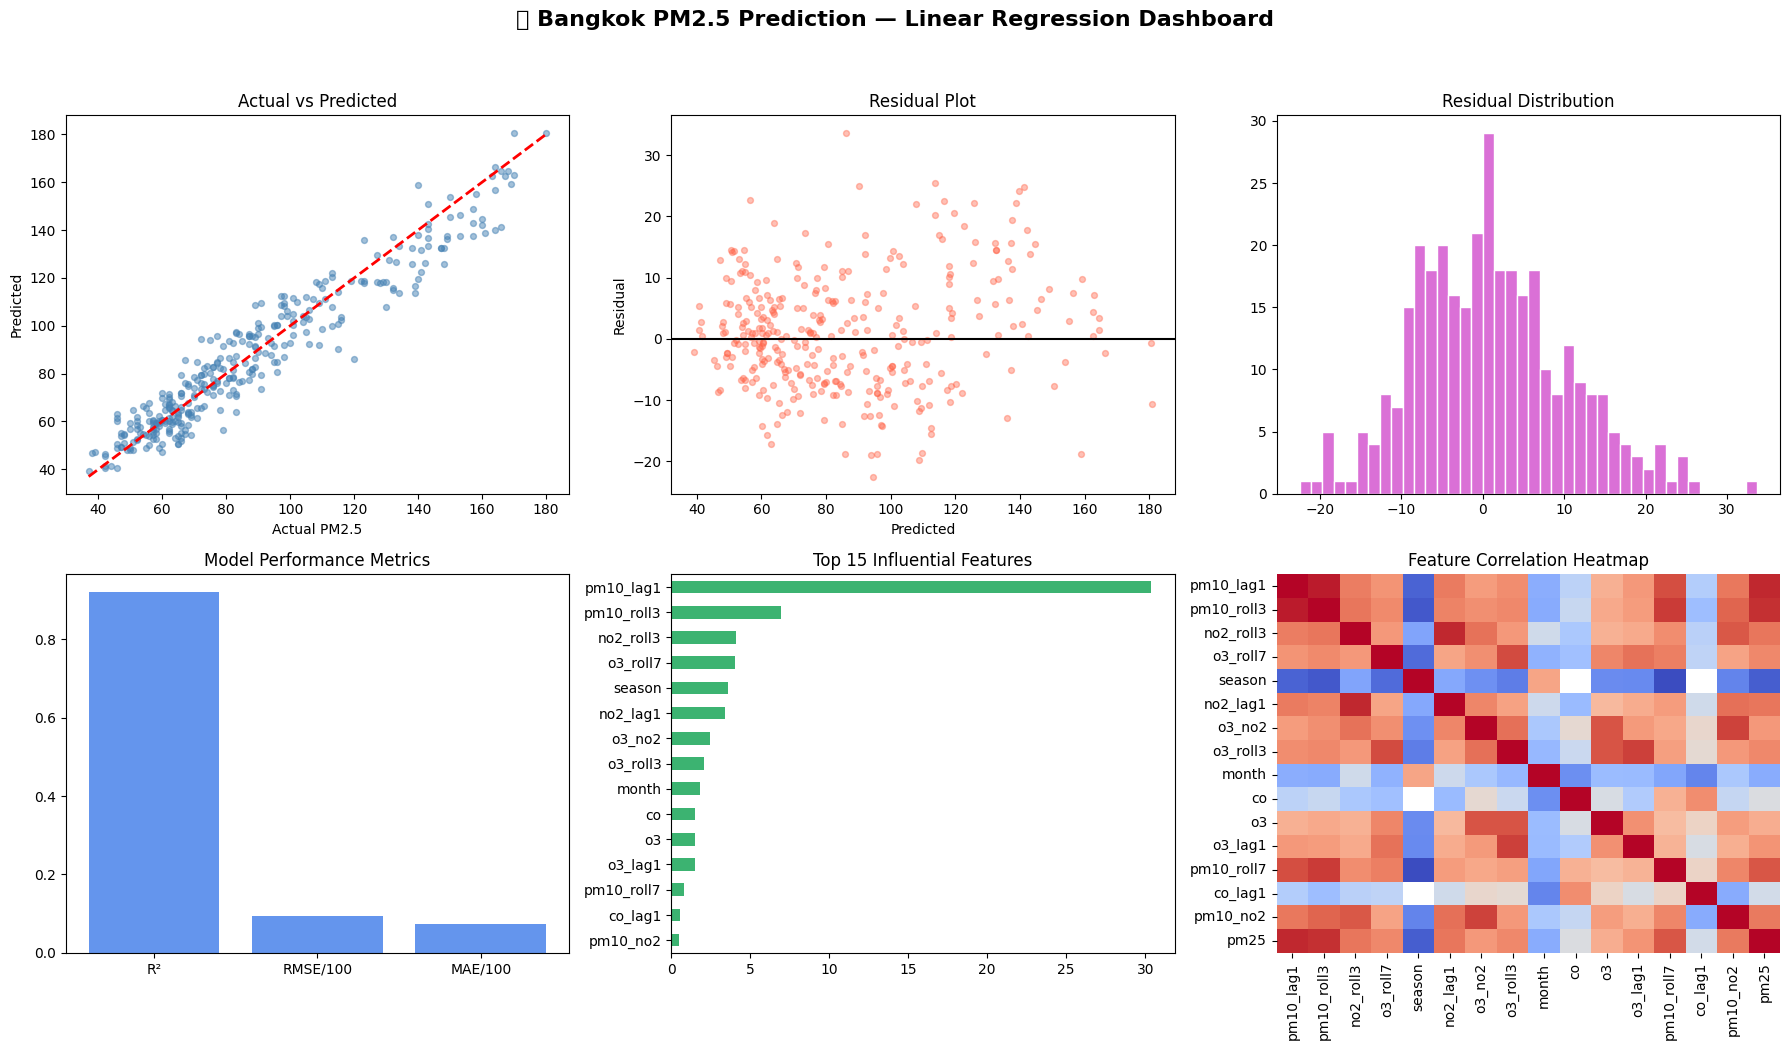

In [ ]:
# ── STEP 10: Visualisations Dashboard ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("📊 Bangkok PM2.5 Prediction — Linear Regression Dashboard", fontsize=16, fontweight="bold")

# 10-A: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color="steelblue", s=18)
lo, hi = y_test.min(), y_test.max()
axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2)
axes[0, 0].set_xlabel("Actual PM2.5"); axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Actual vs Predicted")

# 10-B: Residuals
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.4, color="tomato", s=18)
axes[0, 1].axhline(0, color="black", lw=1.5)
axes[0, 1].set_xlabel("Predicted"); axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("Residual Plot")

# 10-C: Residual distribution
axes[0, 2].hist(residuals, bins=40, color="orchid", edgecolor="white")
axes[0, 2].set_title("Residual Distribution")

# 10-D: Error Metrics Bar
metrics = {'R²': r2, 'RMSE/100': rmse/100, 'MAE/100': mae/100} # Scale เพื่อให้เห็นในกราฟเดียวกัน
axes[1, 0].bar(metrics.keys(), metrics.values(), color='cornflowerblue')
axes[1, 0].set_title("Model Performance Metrics")

# 10-E: Feature Importance (Top 15)
coefs = pd.Series(np.abs(model.coef_), index=feature_cols)
top15 = coefs.nlargest(15)
top15[::-1].plot(kind="barh", ax=axes[1, 1], color="mediumseagreen")
axes[1, 1].set_title("Top 15 Influential Features")

# 10-F: Correlation Heatmap
top_feat = top15.index.tolist()
sns.heatmap(df_model[top_feat + [TARGET]].corr(), ax=axes[1, 2], cmap="coolwarm", cbar=False)
axes[1, 2].set_title("Feature Correlation Heatmap")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ── STEP 11: สรุปผล ────────────────────────────────────────────
print("\n" + "="*55)
print("           📋 LINEAR REGRESSION SUMMARY")
print("="*55)
print(f"   R² Score     : {r2:.4f} ({r2*100:.1f}% Accuracy)")
print(f"   RMSE         : {rmse:.2f} µg/m³")
print(f"   MAE          : {mae:.2f} µg/m³")
print("="*55)


           📋 LINEAR REGRESSION SUMMARY
   R² Score     : 0.9196 (92.0% Accuracy)
   RMSE         : 9.42 µg/m³
   MAE          : 7.41 µg/m³


In [ ]:
# ── STEP 12: ทำนาย PM2.5 ด้วยค่าใหม่ ──────────────────────────
print("🔮 ทดสอบทำนายด้วยค่าใหม่:")

# ตัวอย่าง: pm10=80, o3=12, no2=15, so2=3, co=1.2
sample = pd.DataFrame(np.zeros((1, len(feature_cols))), columns=feature_cols)
sample["pm10"] = 80
sample["o3"] = 12
sample["no2"] = 15
sample["so2"] = 3
sample["co"] = 1.2
sample["month"] = 3
sample["season"] = 0

sample_sc = scaler.transform(sample)
pred_val = model.predict(sample_sc)[0]

print(f"   Input  → pm10=80, o3=12, no2=15, so2=3, co=1.2")
print(f"   Output → Predicted PM2.5 ≈ {pred_val:.2f} µg/m³")

🔮 ทดสอบทำนายด้วยค่าใหม่:
   Input  → pm10=80, o3=12, no2=15, so2=3, co=1.2
   Output → Predicted PM2.5 ≈ 7.85 µg/m³
